--- 8a. Results (Start [0,0] -> Goal [0,1]) ---
BFS: Expanded 3 nodes. Path: [(0, 0), (0, 1)]
DFS: Expanded 2 nodes. Path: [(0, 0), (0, 1)]
Optimality: BFS is optimal (shortest path). DFS is NOT optimal (depends on expansion order).

--- 8b. Fringe Size Data ---
Goal     | BFS Max Fringe  | DFS Max Fringe 
(0, 1)   | 3               | 2              
(0, 2)   | 7               | 3              
(0, 3)   | 15              | 4              
(0, 5)   | 118             | 66             
(0, 6)   | 236             | 66             
(0, 7)   | 356             | 66             
(0, 8)   | 631             | 66             
(0, 9)   | 996             | 66             


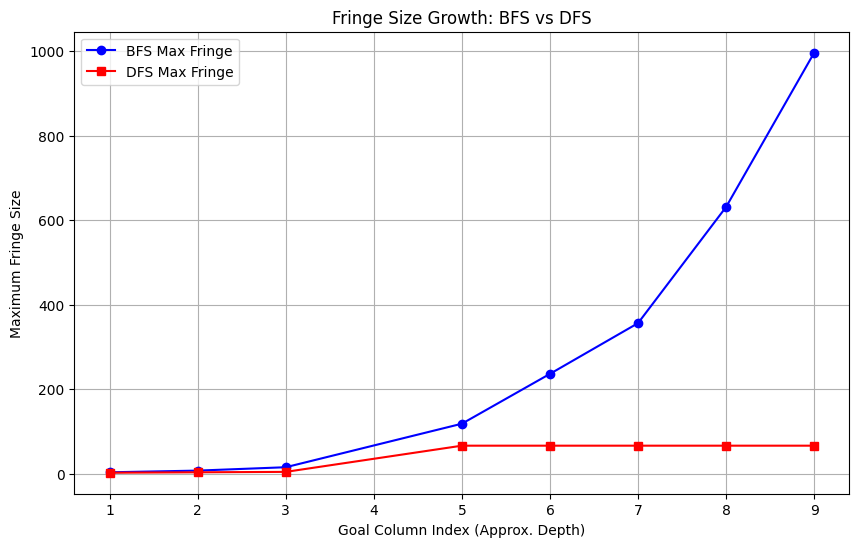

Analysis: DFS fringe grows linearly O(d). BFS fringe grows exponentially O(b^d).

--- 8c. Results for Goal [0,9] ---
BFS Path Length: 12
DFS Path Length: 12
Optimality: BFS found the shortest path (optimal). DFS found a much longer path (not optimal).


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Define the Maze (Figure 7) ---
# 0 = Empty, 1 = Obstacle
maze_layout = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0], # Row 0
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0], # Row 1
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0], # Row 2
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0], # Row 3
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0], # Row 4
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0], # Row 5
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0], # Row 6
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0], # Row 7
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0], # Row 8
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]  # Row 9
]

class Node():
    def __init__(self, parent=None, position=None):
        self.parent = parent
        self.position = position

def get_neighbors(position, maze):
    """Returns valid neighbors (Up, Down, Left, Right)."""
    r, c = position
    rows = len(maze)
    cols = len(maze[0])

    # Standard 4-connectivity (No diagonals, as per Q4/Q9 conventions)
    # Order: Up, Down, Left, Right
    moves = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    neighbors = []
    for dr, dc in moves:
        new_r, new_c = r + dr, c + dc

        # Check bounds and obstacles (0 is walkable)
        if 0 <= new_r < rows and 0 <= new_c < cols and maze[new_r][new_c] == 0:
            neighbors.append((new_r, new_c))

    return neighbors

def blind_search(maze, start, end, method='BFS'):
    # Create start node
    start_node = Node(None, start)
    start_node.position = start

    # Initialize Fringe (Queue for BFS, Stack for DFS)
    fringe = []
    fringe.append(start_node)

    # Track visited to avoid cycles
    visited = []

    # Stats
    nodes_expanded = 0
    max_fringe_size = 0

    while len(fringe) > 0:
        # Update Max Fringe Size
        if len(fringe) > max_fringe_size:
            max_fringe_size = len(fringe)

        # Get Current Node
        # BFS: FIFO (pop(0))
        # DFS: LIFO (In this implementation, we will INSERT at 0 and POP at 0 to mimic stack)

        current_node = fringe.pop(0)
        nodes_expanded += 1

        # Check Goal
        if current_node.position == end:
            path = []
            curr = current_node
            while curr is not None:
                path.append(curr.position)
                curr = curr.parent
            return path[::-1], nodes_expanded, max_fringe_size

        # Mark Visited
        visited.append(current_node.position)

        # Generate Children
        children = get_neighbors(current_node.position, maze)

        for child_pos in children:
            if child_pos in visited:
                continue

            # Create new node
            new_node = Node(current_node, child_pos)

            # Check if in fringe already (optional optimization, but standard blind search often skips)
            # For strict BFS/DFS graph search, we usually check.
            # We'll allow duplicates in fringe if they aren't visited, consistent with Q2/3.

            if method == 'BFS':
                fringe.append(new_node) # Enqueue (End)
            elif method == 'DFS':
                fringe.insert(0, new_node) # Push (Front)

    return None, nodes_expanded, max_fringe_size

# --- Execution for Question 8 ---

# 8a. Start [0,0] -> Goal [0,1]
start_pos = (0, 0)
goal_a = (0, 1)

print("--- 8a. Results (Start [0,0] -> Goal [0,1]) ---")
path_bfs, exp_bfs, _ = blind_search(maze_layout, start_pos, goal_a, 'BFS')
path_dfs, exp_dfs, _ = blind_search(maze_layout, start_pos, goal_a, 'DFS')

print(f"BFS: Expanded {exp_bfs} nodes. Path: {path_bfs}")
print(f"DFS: Expanded {exp_dfs} nodes. Path: {path_dfs}")
print("Optimality: BFS is optimal (shortest path). DFS is NOT optimal (depends on expansion order).\n")


# 8b. Fringe Size Plots (Multiple Goals)
goals = [(0,1), (0,2), (0,3), (0,5), (0,6), (0,7), (0,8), (0,9)]
bfs_max_fringes = []
dfs_max_fringes = []
goal_indices = [g[1] for g in goals]

print("--- 8b. Fringe Size Data ---")
print(f"{'Goal':<8} | {'BFS Max Fringe':<15} | {'DFS Max Fringe':<15}")

for g in goals:
    _, _, bfs_f = blind_search(maze_layout, start_pos, g, 'BFS')
    _, _, dfs_f = blind_search(maze_layout, start_pos, g, 'DFS')

    bfs_max_fringes.append(bfs_f)
    dfs_max_fringes.append(dfs_f)
    print(f"{str(g):<8} | {bfs_f:<15} | {dfs_f:<15}")

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(goal_indices, bfs_max_fringes, marker='o', label='BFS Max Fringe', color='blue')
plt.plot(goal_indices, dfs_max_fringes, marker='s', label='DFS Max Fringe', color='red')
plt.xlabel('Goal Column Index (Approx. Depth)')
plt.ylabel('Maximum Fringe Size')
plt.title('Fringe Size Growth: BFS vs DFS')
plt.legend()
plt.grid(True)
plt.show()

print("Analysis: DFS fringe grows linearly O(d). BFS fringe grows exponentially O(b^d).\n")


# 8c. Path Comparison for Goal [0,9]
goal_c = (0, 9)
path_bfs_c, _, _ = blind_search(maze_layout, start_pos, goal_c, 'BFS')
path_dfs_c, _, _ = blind_search(maze_layout, start_pos, goal_c, 'DFS')

print(f"--- 8c. Results for Goal [0,9] ---")
print(f"BFS Path Length: {len(path_bfs_c)}")
print(f"DFS Path Length: {len(path_dfs_c)}")
print("Optimality: BFS found the shortest path (optimal). DFS found a much longer path (not optimal).")